# Gravitational Sonar v16 — JAX accelerated

Physics preserved from `Sonar_v16_GoldenRun16a`: same metric ansatz,
Hamiltonian, dissipation, RK4 rule, numerical-kludge waveform, Ricci
tensor, boundary condition, loss weights, initial conditions, and
Adam → BFGS/SSBroyden2 schedule.

Backend-only changes:

- one compiled loss/gradient with `jax.jit`
- RK4 time evolution with `jax.lax.scan`
- Ricci, boundary, observer, and diagnostic grids with `jax.vmap`
- quadrupole and polarization loops replaced by equivalent `einsum`
- network stored as a 69-scalar JAX pytree

**Colab:** choose a GPU runtime before running. First call for each
window/dtype compiles; time subsequent calls, not compilation.

## Setup

In [ ]:
# Colab already ships JAX. This only supplies the original custom BFGS patch.
!wget -q -nc https://raw.githubusercontent.com/EliKiani/Optimizing_the_Optimizer_PINNs/main/_optimize.py
!sed -i 's/^from \.\([a-zA-Z_]*\) import/from scipy.optimize.\1 import/' _optimize.py

In [ ]:
import math
import os
import time
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)  # needed by the original BFGS handoff
import jax.numpy as jnp
from jax import lax, random, tree_util
from jax.flatten_util import ravel_pytree
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize
from scipy.optimize import minimize

print("JAX:", jax.__version__)
print("Devices:", jax.devices())
if jax.default_backend() == "cpu":
    print("WARNING: CPU backend. In Colab select Runtime > Change runtime type > GPU.")

Array = jax.Array

JAX: 0.7.2
Devices: [CudaDevice(id=0)]


## Data and physical inputs

In [ ]:
DATA_DIR = Path("/content")
FILE_TAG = "Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1260_observertheta_0.7853981633974483"

t_true, hp_np = np.loadtxt(DATA_DIR / f"waveform_real_{FILE_TAG}.txt", unpack=True)
_, hc_np = np.loadtxt(DATA_DIR / f"waveform_imag_{FILE_TAG}.txt", unpack=True)
soln_true = np.loadtxt(DATA_DIR / f"solution_{FILE_TAG}.txt", unpack=True)

rp_true = 10.0
ra_true = 14.0
a_true = 0.9
theta_min_true = math.pi / 4
theta_observed = jnp.asarray([math.pi / 4], dtype=jnp.float32)

# Exact original grid: 1,000 coordinate-time samples over [0, 1260].
t_full = jnp.linspace(0.0, 1260.0, 1000, dtype=jnp.float32)
hp_full = jnp.asarray(hp_np[: len(t_full)], dtype=jnp.float32)[None, :]
hc_full = jnp.asarray(hc_np[: len(t_full)], dtype=jnp.float32)[None, :]

dt_np = np.diff(np.asarray(t_full))
assert np.allclose(dt_np, dt_np[0], rtol=1e-3), "t must be uniform"
print("samples:", len(t_full), "observers:", len(theta_observed))

samples: 1000 observers: 1


## 69-parameter metric network and unchanged ansatz

In [ ]:
def init_network(key, dtype=jnp.float32):
    # Same Linear(2,8) -> SiLU -> Linear(8,5) architecture: 69 scalars.
    k1, k2, k3, k4 = random.split(key, 4)
    l1 = 1.0 / math.sqrt(2.0)
    l2 = 1.0 / math.sqrt(8.0)
    return {
        "w1": random.uniform(k1, (8, 2), dtype, -l1, l1),
        "b1": random.uniform(k2, (8,), dtype, -l1, l1),
        "w2": random.uniform(k3, (5, 8), dtype, -l2, l2),
        "b2": random.uniform(k4, (5,), dtype, -l2, l2),
    }


def network_apply(params, x):
    hidden = jax.nn.silu(params["w1"] @ x + params["b1"])
    return params["w2"] @ hidden + params["b2"]


def nn_input(r, theta):
    return jnp.stack((1.0 / r, jnp.cos(theta) ** 2))


def Kerr(x, a, M=1.0):
    r, theta = x[1], x[2]
    delta = r**2 - 2.0 * M * r + a**2
    sigma = r**2 + a**2 * jnp.cos(theta) ** 2
    A = (r**2 + a**2) ** 2 - delta * a**2 * jnp.sin(theta) ** 2
    g_tt = -(1.0 - 2.0 * M * r / sigma)
    g_rr = sigma / delta
    g_thth = sigma
    g_phph = A / sigma * jnp.sin(theta) ** 2
    g_tph = (-2.0 * M * r / sigma) * a * jnp.sin(theta) ** 2
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))


def g_Kerr(r, theta, M=1.0, a=a_true):
    return Kerr(jnp.stack((jnp.zeros_like(r), r, theta, jnp.zeros_like(r))), a, M)


def NN_Ansatz(r, theta, fields):
    u = 1.0 / r
    g_tt = -1.0 + u * fields[0]
    g_rr = 1.0 / (1.0 + u * fields[1])
    g_thth = r**2 + fields[2]
    g_phph = jnp.sin(theta) ** 2 * (r**2 + fields[3])
    g_tph = u * jnp.sin(theta) ** 2 * fields[4]
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))


def metric_from_network(params, r, theta):
    return NN_Ansatz(r, theta, network_apply(params, nn_input(r, theta)))


params = init_network(random.PRNGKey(0))
flat0, _ = ravel_pytree(params)
assert flat0.size == 69
print("parameters:", flat0.size, "test output:", network_apply(params, jnp.array([2.0, 1.57])))

parameters: 69 test output: [-0.61378847  0.65292454  0.55026903 -0.2847634  -0.58163525]


In [ ]:
R_LO, R_HI = 6.2, 20.0
TH_LO, TH_HI = 0.1, math.pi/2 - 0.1

def logit(x):
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    return jnp.log(x) - jnp.log1p(-x)

def inv_softplus(x):
    return jnp.log(jnp.expm1(x))

def encode_ic(r, theta, pt, Lz):
    return jnp.asarray([
        logit((r - R_LO) / (R_HI - R_LO)),
        logit((theta - TH_LO) / (TH_HI - TH_LO)),
        inv_softplus(-pt),
        inv_softplus(Lz),
    ], dtype=jnp.float32)

def decode_ic(z):
    r = R_LO + (R_HI - R_LO) * jax.nn.sigmoid(z[0])
    theta = TH_LO + (TH_HI - TH_LO) * jax.nn.sigmoid(z[1])
    pt = -jax.nn.softplus(z[2])
    Lz = jax.nn.softplus(z[3])
    return jnp.asarray([0., r, theta, 0., pt, 0., 0., Lz])

params = {
    "metric": params,
    "ic": encode_ic(9.0, 0.90, -0.90, 2.30),
}

assert ravel_pytree(params)[0].size == 73

## Initial conditions — unchanged Kerr map, evaluated once outside JIT

In [ ]:
def solve_ELQ(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    delta_p = r_p**2 - 2.0 * M * r_p + a**2
    delta_a = r_a**2 - 2.0 * M * r_a + a**2

    def equations(v):
        E, Lz = v
        Qp = (((r_p**2 + a**2) * E - a * Lz) ** 2
              - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p
        F0 = (((r_a**2 + a**2) * E - a * Lz) ** 2
              - delta_a * ((Lz - a * E) ** 2 + mu**2 * r_a**2 + Qp))
        F1 = Qp - math.cos(theta_min) ** 2 * (
            a**2 * (mu**2 - E**2) + Lz**2 / math.sin(theta_min) ** 2
        )
        return (F0, F1)

    E0 = math.sqrt(1.0 - 2.0 * M / (r_p + r_a))
    L0 = math.sqrt(M * (r_p + r_a) / 2.0)
    E, Lz = optimize.fsolve(equations, (E0, L0))
    Q = ((((r_p**2 + a**2) * E - a * Lz) ** 2
         - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p)
    return E, Lz, Q


def make_u0(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    E, Lz, _ = solve_ELQ(r_p, r_a, theta_min, M, a, mu)
    return np.asarray([0.0, r_p, theta_min, 0.0, -E, 0.0, 0.0, Lz])


# solve_ELQ is not part of training AD: original ICs are fixed.
U0 = jnp.asarray(make_u0(rp_true, ra_true, theta_min_true), dtype=jnp.float64)
print("u0:", U0)

u0: [ 0.         10.          0.78539816  0.         -0.96048519  0.
  0.          2.66185247]


## Hamiltonian and RK4 — same equations, `lax.scan` time loop

In [ ]:
I4 = jnp.eye(4)
Z4 = jnp.zeros((4, 4))
SYMPLECTIC = jnp.block([[Z4, I4], [-I4, Z4]])
DISSIPATION = -10e-4 * jnp.asarray([0, 0, 0, 0, 0, 0, 0, 1])


def hamiltonian_network(params, state):
    _, r, theta, _, p_t, p_r, p_theta, p_phi = state
    inv_g = jnp.linalg.inv(metric_from_network(params, r, theta))
    p = jnp.stack((p_t, p_r, p_theta, p_phi))
    return 0.5 * p @ inv_g @ p


def H_function(params, state):
    grad_H = jax.grad(hamiltonian_network, argnums=1)(params, state)
    du_dtau = SYMPLECTIC.astype(state.dtype) @ grad_H + DISSIPATION.astype(state.dtype)
    du = du_dtau / grad_H[4]
    return du.at[0].set(1.0)


def hamiltonian_kerr(state):
    inv_g = jnp.linalg.inv(Kerr(state[:4], a_true))
    return 0.5 * state[4:] @ inv_g @ state[4:]


def H_Kerr(state):
    grad_H = jax.grad(hamiltonian_kerr)(state)
    du_dtau = SYMPLECTIC.astype(state.dtype) @ grad_H + DISSIPATION.astype(state.dtype)
    du = du_dtau / grad_H[4]
    return du.at[0].set(1.0)


def rk4_step(rhs, time, state, step):
    k1 = rhs(time, state)
    k2 = rhs(time + step / 2.0, state + step * k1 / 2.0)
    k3 = rhs(time + step / 2.0, state + step * k2 / 2.0)
    k4 = rhs(time + step, state + step * k3)
    return state + step * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0


def integrate(rhs, y0, t_array):
    step = t_array[1] - t_array[0]

    def scan_step(state, time):
        next_state = rk4_step(rhs, time, state, step)
        return next_state, next_state

    _, tail = lax.scan(scan_step, y0, t_array[:-1])
    return jnp.concatenate((y0[None, :], tail), axis=0)


def integrate_network(params, y0, t_array):
    return integrate(lambda time, state: H_function(params, state), y0, t_array)


def integrate_kerr(y0, t_array):
    return integrate(lambda time, state: H_Kerr(state), y0, t_array)

## Numerical-kludge waveform — identical algebra, vectorized

In [ ]:
def d2_dt2(v, dt):
    first = 2.0 * v[..., 0] - 5.0 * v[..., 1] + 4.0 * v[..., 2] - v[..., 3]
    middle = v[..., :-2] - 2.0 * v[..., 1:-1] + v[..., 2:]
    last = 2.0 * v[..., -1] - 5.0 * v[..., -2] + 4.0 * v[..., -3] - v[..., -4]
    return jnp.concatenate((first[..., None], middle, last[..., None]), axis=-1) / dt**2


def Soln2Orbit(soln, a):
    r, theta, phi = soln[:, 1], soln[:, 2], soln[:, 3]
    return jnp.stack((
        r * jnp.sin(theta) * jnp.cos(phi),
        r * jnp.sin(theta) * jnp.sin(phi),
        r * jnp.cos(theta),
    ))


def Q_ij(orbit, mu=1.0):
    outer = jnp.einsum("in,jn->ijn", orbit, orbit)
    r2 = jnp.sum(orbit**2, axis=0)
    return mu * (outer - jnp.eye(3, dtype=orbit.dtype)[:, :, None] * r2[None, None, :] / 3.0)


def Observer_Basis(theta_obs, phi_obs):
    n = jnp.stack((jnp.sin(theta_obs) * jnp.cos(phi_obs),
                   jnp.sin(theta_obs) * jnp.sin(phi_obs),
                   jnp.cos(theta_obs)))
    p = jnp.stack((jnp.cos(theta_obs) * jnp.cos(phi_obs),
                   jnp.cos(theta_obs) * jnp.sin(phi_obs),
                  -jnp.sin(theta_obs)))
    q = jnp.stack((-jnp.sin(phi_obs), jnp.cos(phi_obs), jnp.zeros_like(phi_obs)))
    return n, p, q


def project_waveform(Qdd, theta_obs=0.0, phi_obs=0.0, D=1.0):
    _, p, q = Observer_Basis(theta_obs, phi_obs)
    e_plus = jnp.einsum("i,j->ij", p, p) - jnp.einsum("i,j->ij", q, q)
    e_cross = jnp.einsum("i,j->ij", p, q) + jnp.einsum("i,j->ij", q, p)
    return (jnp.einsum("ij,ijn->n", e_plus, Qdd) / D,
            jnp.einsum("ij,ijn->n", e_cross, Qdd) / D)


def create_gravityWave(t_array, soln, a, mu=1.0, theta_obs=0.0, phi_obs=0.0, D=1.0):
    orbit = Soln2Orbit(soln, a)
    Qdd = d2_dt2(Q_ij(orbit, mu), t_array[1] - t_array[0])
    return project_waveform(Qdd, theta_obs, phi_obs, D)

## Curvature and boundary terms — full-grid `vmap`

In [ ]:
def christ_awful(metric, x):
    partial_g = jax.jacfwd(metric)(x)
    ginv = jnp.linalg.inv(metric(x))
    term1 = jnp.einsum("ms,sab->mab", ginv, partial_g)
    term2 = jnp.einsum("ms,sba->mab", ginv, partial_g)
    term3 = jnp.einsum("ms,abs->mab", ginv, partial_g)
    return 0.5 * (term1 + term2 - term3)


def Riemann(metric, x):
    dGamma = jax.jacfwd(lambda y: christ_awful(metric, y))(x)
    Gamma = christ_awful(metric, x)  # one evaluation; original recomputed it four times
    term1 = jnp.einsum("abvu->abuv", dGamma)
    term2 = jnp.einsum("abuv->abuv", dGamma)
    term3 = jnp.einsum("aup,pbv->abuv", Gamma, Gamma)
    term4 = jnp.einsum("avp,pbu->abuv", Gamma, Gamma)
    return term1 - term2 + term3 - term4


def Ricci(metric, x):
    return jnp.einsum("abav->bv", Riemann(metric, x))


R_INNER = jnp.logspace(math.log10(2.0), math.log10(20.0), 20)
R_OUTER = jnp.asarray([30.0, 50.0, 100.0, 200.0])
THETA_RICCI = jnp.linspace(math.pi / 20.0, math.pi / 2.0, 4)
RR, TT = jnp.meshgrid(jnp.concatenate((R_INNER, R_OUTER)), THETA_RICCI, indexing="ij")
RICCI_POINTS = jnp.stack((jnp.zeros(RR.size), RR.ravel(), TT.ravel(), jnp.zeros(RR.size)), axis=1)
BC_R = jnp.linspace(1.0, 2.01, 80)
BC_THETA = jnp.linspace(0.0, math.pi / 2.0, 4)


def ricci_loss(params):
    metric = lambda x: metric_from_network(params, x[1], x[2])
    points = RICCI_POINTS.astype(params["w1"].dtype)
    values = jax.vmap(lambda x: Ricci(metric, x))(points)
    return jnp.mean(jnp.sum(values**2, axis=(1, 2)))


def boundaryConditionLoss(params):
    dtype = params["w1"].dtype
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((jnp.zeros_like(r_vals), r_vals,
                            jnp.full_like(r_vals, theta), jnp.zeros_like(r_vals)), axis=1)
        residuals = jax.vmap(
            lambda x: 1.0 / metric_from_network(params, x[1], x[2])[1, 1]
        )(points)
        weights = jax.nn.softmax(-(residuals**2) / tau)
        root = jnp.sum(weights * r_vals)
        root_residual = 1.0 / metric_from_network(params, root, theta)[1, 1]
        sign_penalty = jax.nn.relu(residuals[0] * residuals[-1])
        return root, root_residual**2, sign_penalty

    roots, root_residuals, sign_penalties = jax.vmap(one_theta)(theta_vals)
    # torch.var default used correction=1; preserve that convention.
    location_consistency = jnp.var(roots, ddof=1)
    total = location_consistency + jnp.mean(root_residuals) + jnp.mean(sign_penalties)
    return total, roots

## Loss — one compiled value/gradient

In [ ]:
def mass_shell_loss(metric_params, u0):
    g = metric_from_network(metric_params, u0[1], u0[2])
    p = u0[4:]
    return (p @ jnp.linalg.inv(g) @ p + 1.0)**2


def hann_periodic(N, dtype):
    n = jnp.arange(N, dtype=dtype)
    return 0.5 * (1.0 - jnp.cos(2.0 * jnp.pi * n / N))


def SpectralLoss(h_true, h_pred):
    window = hann_periodic(h_true.shape[0], h_true.real.dtype)
    true_mag = jnp.abs(jnp.fft.fft(window * h_true))
    pred_mag = jnp.abs(jnp.fft.fft(window * h_pred))
    eps = 1e-4 * jnp.mean(true_mag**2)
    return jnp.mean((true_mag - pred_mag) ** 2 / (true_mag**2 + eps))

def waveform_loss(metric_params, u0, t_array, hp_true, hc_true, eps=1e-12):
    trajectory = integrate_network(metric_params, u0, t_array)
    observers = theta_observed.astype(metric_params["w1"].dtype)

    hp_pred, hc_pred = jax.vmap(
        lambda theta: create_gravityWave(
            t_array, trajectory, a_true, theta_obs=theta
        )
    )(observers)

    squared_error = jnp.mean(
        (hp_pred - hp_true)**2 + (hc_pred - hc_true)**2,
        axis=1,
    )
    truth_power = lax.stop_gradient(
        jnp.mean(hp_true**2 + hc_true**2, axis=1)
    )

    return (
        jnp.mean(squared_error / (truth_power + eps)),
        hp_pred,
        hc_pred,
    )


LOSS_WEIGHTS = jnp.asarray([1.0, 0.5, 0.1, 0.1])
P_MASS_SHELL = 10.0


def loss(joint, t_array, hp_true, hc_true, weights):
    metric_params = joint["metric"]
    u0 = decode_ic(joint["ic"])

    waveformLoss, hp_pred, hc_pred = waveform_loss(
        metric_params, u0, t_array, hp_true, hc_true
    )
    ricciLoss = ricci_loss(metric_params)
    boundaryLoss, roots = boundaryConditionLoss(metric_params)
    frequencyLoss = SpectralLoss(
        hp_true[0] + 1j * hc_true[0],
        hp_pred[0] + 1j * hc_pred[0],
    )
    shellLoss = mass_shell_loss(metric_params, u0)

    components = jnp.stack((
        waveformLoss,
        ricciLoss,
        frequencyLoss,
        boundaryLoss,
    ))

    total = (
        jnp.dot(weights.astype(components.dtype), components)
        + P_MASS_SHELL * shellLoss
    )

    return total, (components, roots, shellLoss, u0)


loss_value_and_grad = jax.jit(
    jax.value_and_grad(loss, argnums=0, has_aux=True)
)
loss_only = jax.jit(loss)

## Physics gates

In [ ]:
@jax.jit
def exact_kerr_gate(t_array):
    trajectory = integrate_kerr(U0.astype(t_array.dtype), t_array)
    return trajectory, create_gravityWave(
        t_array, trajectory, a_true, theta_obs=theta_observed[0].astype(t_array.dtype)
    )


trajectory_gate, (hp_gate, hc_gate) = exact_kerr_gate(t_full)
relative_L2 = 100.0 * jnp.linalg.norm((hp_gate + 1j * hc_gate) - (hp_full[0] + 1j * hc_full[0])) / (
    jnp.linalg.norm(hp_full[0] + 1j * hc_full[0]) + 1e-12
)
print("Exact-Kerr waveform L2 error (%):", float(relative_L2))

x_gate = jnp.asarray([0.0, 10.0, math.pi / 2.0, 0.0], dtype=jnp.float64)
print("Kerr Ricci gate:\n", Ricci(lambda x: Kerr(x, a_true), x_gate))
assert np.isfinite(np.asarray(relative_L2))

Exact-Kerr waveform L2 error (%): 0.3517760932445526
Kerr Ricci gate:
 [[ 2.16840434e-19  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  6.93889390e-18 -1.03518735e-33  0.00000000e+00]
 [ 0.00000000e+00 -3.55093333e-33  5.55111512e-17  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  9.43689571e-16]]


## Checkpoints

In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    SAVE_DIR = Path("/content/drive/MyDrive")
except ImportError:
    SAVE_DIR = Path(".")

RUN_ID = "joint_ic_metric_seed0"

CHECKPOINT_PATH = SAVE_DIR / f"{RUN_ID}_live.npz"
FINAL_PATH = SAVE_DIR / f"{RUN_ID}_final.npz"

RESUME = False


def save_checkpoint(path, params, stage_idx, epoch, n, histories):
    flat, _ = ravel_pytree(params)
    np.savez(
        path,
        flat_params=np.asarray(jax.device_get(flat)),
        stage_idx=stage_idx,
        epoch=epoch,
        n=n,
        **{name: np.asarray(values) for name, values in histories.items()},
    )


def load_checkpoint(path, template):
    if not Path(path).exists():
        return None
    data = np.load(path)
    _, unravel = ravel_pytree(template)
    loaded = unravel(jnp.asarray(data["flat_params"]))
    names = ("total", "waveform", "ricci", "frequency", "boundary", "mass_shell")
    histories = {
        name: data[name].tolist() if name in data else []
        for name in names
    }
    return loaded, int(data["stage_idx"]), int(data["epoch"]), int(data["n"]), histories


def import_pytorch_checkpoint(path):
    '''Optional one-time import of the original .pt network weights.'''
    import torch
    payload = torch.load(path, map_location="cpu")
    state = payload.get("net_state", payload)
    return {
        "w1": jnp.asarray(state["fc1.weight"].detach().numpy()),
        "b1": jnp.asarray(state["fc1.bias"].detach().numpy()),
        "w2": jnp.asarray(state["fc2.weight"].detach().numpy()),
        "b2": jnp.asarray(state["fc2.bias"].detach().numpy()),
    }

# To continue from a trained PyTorch model, uncomment before training:
# params = import_pytorch_checkpoint("/content/drive/MyDrive/sonar_v16_final.pt")

Mounted at /content/drive


## Adam — same curriculum, JIT loss/gradient

In [ ]:
def tree_zeros_like(tree):
    return tree_util.tree_map(jnp.zeros_like, tree)


def global_norm(tree):
    return jnp.sqrt(sum(jnp.vdot(x, x).real for x in tree_util.tree_leaves(tree)))


@jax.jit
def adam_update(params, grads, state, learning_rate):
    count, m, v = state
    count = count + 1
    grad_norm = global_norm(grads)
    scale = jnp.minimum(1.0, 1.0 / (grad_norm + 1e-12))
    grads = tree_util.tree_map(lambda g: g * scale, grads)
    m = tree_util.tree_map(lambda old, g: 0.9 * old + 0.1 * g, m, grads)
    v = tree_util.tree_map(lambda old, g: 0.999 * old + 0.001 * g * g, v, grads)
    mhat = tree_util.tree_map(lambda x: x / (1.0 - 0.9**count), m)
    vhat = tree_util.tree_map(lambda x: x / (1.0 - 0.999**count), v)
    params = tree_util.tree_map(
        lambda p, mm, vv: p - learning_rate * mm / (jnp.sqrt(vv) + 1e-8),
        params, mhat, vhat,
    )
    return params, (count, m, v), grad_norm


def metric_errors(params):
    metric_params = params["metric"]

    radii = jnp.asarray(
        [2, 3, 4, 5, 6, 12, 20],
        dtype=metric_params["w1"].dtype,
    )
    angles = jnp.asarray(
        [math.pi / 20, math.pi / 4, math.pi / 3, math.pi / 2],
        dtype=metric_params["w1"].dtype,
    )

    def errors_at_r(r):
        pred = jax.vmap(
            lambda th: metric_from_network(metric_params, r, th)
        )(angles)

        true = jax.vmap(
            lambda th: g_Kerr(r, th)
        )(angles)

        ij = jnp.asarray([
            [0, 0],
            [1, 1],
            [2, 2],
            [3, 3],
            [0, 3],
        ])

        return jax.vmap(
            lambda pair:
                100.0
                * jnp.linalg.norm(
                    pred[:, pair[0], pair[1]]
                    - true[:, pair[0], pair[1]]
                )
                / (
                    jnp.linalg.norm(
                        true[:, pair[0], pair[1]]
                    )
                    + 1e-12
                )
        )(ij)

    return jax.vmap(errors_at_r)(radii).T


metric_errors_jit = jax.jit(metric_errors)

histories = {name: [] for name in (
    "total", "waveform", "ricci",
    "frequency", "boundary", "mass_shell"
)}
schedule = [(25, 45), (50, 40), (100, 35)]  # exact original warm-up
n = 0
start_stage_idx = 0
start_epoch = 0

if RESUME:
    restored = load_checkpoint(CHECKPOINT_PATH, params)
    if restored is not None:
        params, start_stage_idx, saved_epoch, n, histories = restored
        start_epoch = saved_epoch + 1
        print("resumed:", start_stage_idx, start_epoch, n)

adam_state = (jnp.asarray(0), tree_zeros_like(params), tree_zeros_like(params))
start_time = time.time()
LOG_EVERY = 10  # logging only; physics/loss unchanged

for stage_idx, (window, epochs) in enumerate(schedule):
    if stage_idx < start_stage_idx:
        continue
    t_window = t_full[:window]
    hp_window = hp_full[:, :window]
    hc_window = hc_full[:, :window]
    epoch0 = start_epoch if stage_idx == start_stage_idx else 0
    learning_rate = jnp.asarray(1e-2, dtype=params["metric"]["w1"].dtype)
    print(f"\nAdam {stage_idx + 1}/{len(schedule)}: [0:{window}], {epochs} iterations")

    for epoch in range(epoch0, epochs):
        (value_aux, grads) = loss_value_and_grad(
            params, t_window, hp_window, hc_window, LOSS_WEIGHTS
        )
        total, (components, roots, shell, u0_fit) = value_aux
        params, adam_state, grad_norm = adam_update(params, grads, adam_state, learning_rate)
        total.block_until_ready()

        if (n + 1) % 10 == 0:
          print(
              f"r0={float(u0_fit[1]):.6f}  "
              f"theta0={float(u0_fit[2]):.6f}  "
              f"E0={float(-u0_fit[4]):.6f}  "
              f"Lz0={float(u0_fit[7]):.6f}  "
              f"shell={float(shell):.3e}"
          )

        values = np.asarray(jax.device_get(components))
        histories["total"].append(float(total))
        for name, value, weight in zip(
            ("waveform", "ricci", "frequency", "boundary"), values, np.asarray(LOSS_WEIGHTS)
        ):
            histories[name].append(float(weight * value))
        histories["mass_shell"].append(
            float(P_MASS_SHELL * shell)
        )
        n += 1
        if n == 1 or n % LOG_EVERY == 0:
            elapsed = time.time() - start_time
            print(f"iter={n:4d} time={elapsed:7.1f}s total={float(total):.3e} "
                  f"W={values[0]:.2e} R={values[1]:.2e} F={values[2]:.2e} "
                  f"BC={values[3]:.2e} r_H={float(jnp.mean(roots)):.4f} |g|={float(grad_norm):.2e}")
        if n % 10 == 0:
            save_checkpoint(CHECKPOINT_PATH, params, stage_idx, epoch, n, histories)

    save_checkpoint(CHECKPOINT_PATH, params, stage_idx, epochs - 1, n, histories)

print("Adam complete:", n, "iterations")


Adam 1/3: [0:25], 45 iterations
iter=   1 time=   25.8s total=3.949e+00 W=2.49e+00 R=2.18e-02 F=4.63e-01 BC=2.98e+00 r_H=2.0100 |g|=1.68e+01
r0=9.204384  theta0=0.929401  E0=0.954460  Lz0=2.219931  shell=3.713e-02
iter=  10 time=   26.3s total=1.510e+00 W=8.85e-01 R=2.84e-03 F=3.47e-01 BC=2.17e+00 r_H=2.0100 |g|=7.81e+00
r0=9.428261  theta0=0.959142  E0=1.017487  Lz0=2.135533  shell=6.214e-04
iter=  20 time=   28.5s total=5.050e-01 W=3.44e-01 R=8.16e-04 F=2.64e-01 BC=1.28e+00 r_H=1.0000 |g|=1.29e+00
r0=9.567104  theta0=0.978205  E0=1.044380  Lz0=2.077439  shell=4.945e-03
iter=  30 time=   28.7s total=3.773e-01 W=2.71e-01 R=1.95e-03 F=2.10e-01 BC=3.49e-01 r_H=1.0000 |g|=2.22e+00
r0=9.528722  theta0=0.976255  E0=1.007641  Lz0=2.083001  shell=7.845e-06
iter=  40 time=   29.0s total=2.669e-01 W=2.45e-01 R=6.57e-03 F=1.78e-01 BC=2.34e-03 r_H=1.0647 |g|=3.48e-01

Adam 2/3: [0:50], 40 iterations
r0=9.401671  theta0=0.964439  E0=0.988562  Lz0=2.101414  shell=2.029e-04
iter=  50 time=   53.9s 

## Float64 BFGS / SSBroyden2 — same continuation schedule

In [ ]:
# Original handoff precision. Note: consumer GPUs have weak float64 throughput.
params = tree_util.tree_map(lambda x: x.astype(jnp.float64), params)
t_full = t_full.astype(jnp.float64)
hp_full = hp_full.astype(jnp.float64)
hc_full = hc_full.astype(jnp.float64)
LOSS_WEIGHTS = LOSS_WEIGHTS.astype(jnp.float64)

try:
    import _optimize as ssbroyden_patch
    import scipy.optimize._minimize as scipy_dispatch
    import scipy.optimize._optimize as scipy_internal
    scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs
    scipy_dispatch._minimize_bfgs = ssbroyden_patch._minimize_bfgs
    USE_SSBROYDEN2 = True
    print("BFGS inverse-Hessian update: SSBroyden2")
except (ImportError, AttributeError) as exc:
    USE_SSBROYDEN2 = False
    print("SSBroyden2 patch unavailable; using stock SciPy BFGS:", exc)

LAST_GOOD = {"x": None, "f": None}
BAD_EVALS = {"n": 0, "last": ""}


def run_bfgs_stage(window, maxiter, params, weights):
    t_window = t_full[:window]
    hp_window = hp_full[:, :window]
    hc_window = hc_full[:, :window]
    x0, unravel = ravel_pytree(params)
    x0 = np.asarray(jax.device_get(x0), dtype=np.float64)

    def loss_and_gradient(x, reject_bad=True, record=True):
        try:
            trial = unravel(jnp.asarray(x, dtype=jnp.float64))
            (value_aux, grads) = loss_value_and_grad(
                trial, t_window, hp_window, hc_window, weights
            )
            value, (components, _, shell, u0_fit) = value_aux
            grad, _ = ravel_pytree(grads)
            value_np = float(jax.device_get(value))
            grad_np = np.asarray(jax.device_get(grad), dtype=np.float64)
            if not np.isfinite(value_np) or not np.isfinite(grad_np).all():
                raise FloatingPointError("non-finite loss/gradient")
            if record:
                values = np.asarray(jax.device_get(components))
                histories["total"].append(value_np)
                for name, raw, weight in zip(
                    ("waveform", "ricci", "frequency", "boundary"), values, np.asarray(weights)
                ):
                    histories[name].append(float(weight * raw))
                histories["mass_shell"].append(float(P_MASS_SHELL * shell))
            LAST_GOOD.update(x=np.asarray(x).copy(), f=value_np)
            return value_np, grad_np
        except (FloatingPointError, RuntimeError) as exc:
            if not reject_bad:
                raise
            BAD_EVALS["n"] += 1
            BAD_EVALS["last"] = repr(exc)[:200]
            xv = np.asarray(x, dtype=np.float64)
            xref = LAST_GOOD["x"] if LAST_GOOD["x"] is not None else xv
            fref = LAST_GOOD["f"] if LAST_GOOD["f"] is not None else 1.0
            delta = xv - xref
            return float(fref * (1.0 + delta @ delta)), 2.0 * fref * delta

    gate_loss, gate_grad = loss_and_gradient(x0, reject_bad=False, record=False)
    print(f"[0:{window}] gate loss={gate_loss:.3e} |grad|={np.linalg.norm(gate_grad):.3e}")
    assert np.isfinite(gate_loss) and np.isfinite(gate_grad).all()
    assert np.linalg.norm(gate_grad) > 1e-12

    stage_start = time.time()

    def callback(intermediate_result):
        # The parameter name asks modern SciPy for an OptimizeResult;
        # the ndarray fallback keeps compatibility with older patches.
        accepted_x = (intermediate_result.x if hasattr(intermediate_result, "x")
                      else np.asarray(intermediate_result))
        accepted_fun = (float(intermediate_result.fun) if hasattr(intermediate_result, "fun")
                        else LAST_GOOD["f"])
        LAST_GOOD.update(x=np.asarray(accepted_x).copy(), f=accepted_fun)
        accepted_params = unravel(jnp.asarray(accepted_x, dtype=jnp.float64))
        save_checkpoint(CHECKPOINT_PATH, accepted_params, len(schedule) - 1,
                        schedule[-1][1] - 1, n, histories)
        print(f"BFGS accepted loss={accepted_fun:.3e} elapsed={(time.time()-stage_start):.1f}s")

    options = {"maxiter": maxiter, "gtol": 1e-6, "disp": True}
    if USE_SSBROYDEN2:
        options.update(method_bfgs="SSBroyden2", initial_scale=True)
    result = minimize(loss_and_gradient, x0, jac=True, method="BFGS",
                      callback=callback, options=options)
    final_params = unravel(jnp.asarray(result.x, dtype=jnp.float64))
    save_checkpoint(SAVE_DIR / f"{RUN_ID}_w{window}.npz", final_params,
                    len(schedule) - 1, schedule[-1][1] - 1, n, histories)
    print(f"[0:{window}] done loss={result.fun:.3e} iters={result.nit} "
          f"evals={result.nfev} bad={BAD_EVALS['n']} {BAD_EVALS['last']}")
    return final_params, result


bfgs_start = time.time()
for window, maxiter in [(200, 30), (400, 30), (600, 30), (800, 50)]:
    params, result = run_bfgs_stage(window, maxiter, params, LOSS_WEIGHTS)

LOSS_WEIGHTS = LOSS_WEIGHTS.at[1].set(2.0)  # original late P_RICCI change
for window, maxiter in [(900, 20), (950, 20), (975, 20), (990, 20), (1000, 500)]:
    params, result = run_bfgs_stage(window, maxiter, params, LOSS_WEIGHTS)

print("BFGS minutes:", (time.time() - bfgs_start) / 60.0)
print("final loss:", result.fun, "success:", result.success, result.message)

BFGS inverse-Hessian update: SSBroyden2
[0:200] gate loss=6.970e-02 |grad|=1.253e+01
BFGS accepted loss=5.420e-02 elapsed=1.3s
BFGS accepted loss=5.392e-02 elapsed=1.5s
BFGS accepted loss=5.386e-02 elapsed=2.0s
BFGS accepted loss=5.137e-02 elapsed=2.7s
BFGS accepted loss=4.695e-02 elapsed=3.0s
BFGS accepted loss=4.153e-02 elapsed=3.2s
BFGS accepted loss=4.092e-02 elapsed=3.5s
BFGS accepted loss=4.055e-02 elapsed=3.7s
BFGS accepted loss=3.996e-02 elapsed=4.0s
BFGS accepted loss=3.925e-02 elapsed=4.2s
BFGS accepted loss=3.823e-02 elapsed=4.5s
BFGS accepted loss=3.650e-02 elapsed=4.7s
BFGS accepted loss=3.443e-02 elapsed=5.0s
BFGS accepted loss=3.376e-02 elapsed=5.2s
BFGS accepted loss=3.286e-02 elapsed=5.5s
BFGS accepted loss=3.183e-02 elapsed=5.7s
BFGS accepted loss=3.003e-02 elapsed=6.0s
BFGS accepted loss=2.705e-02 elapsed=6.2s
BFGS accepted loss=2.320e-02 elapsed=6.5s
BFGS accepted loss=2.124e-02 elapsed=6.7s
BFGS accepted loss=1.968e-02 elapsed=7.0s
BFGS accepted loss=1.846e-02 elap

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


[0:400] gate loss=4.956e-01 |grad|=1.083e+02
BFGS accepted loss=2.223e-01 elapsed=2.8s
BFGS accepted loss=2.178e-01 elapsed=3.3s
BFGS accepted loss=2.175e-01 elapsed=3.8s
BFGS accepted loss=2.047e-01 elapsed=5.2s
BFGS accepted loss=1.876e-01 elapsed=5.7s
BFGS accepted loss=1.587e-01 elapsed=6.2s
BFGS accepted loss=1.262e-01 elapsed=6.7s
BFGS accepted loss=1.194e-01 elapsed=7.2s
BFGS accepted loss=1.078e-01 elapsed=7.7s
BFGS accepted loss=9.074e-02 elapsed=8.1s
BFGS accepted loss=8.154e-02 elapsed=8.6s
BFGS accepted loss=7.811e-02 elapsed=9.1s
BFGS accepted loss=7.215e-02 elapsed=9.6s
BFGS accepted loss=6.484e-02 elapsed=10.1s
BFGS accepted loss=5.715e-02 elapsed=10.6s
BFGS accepted loss=5.407e-02 elapsed=11.1s
BFGS accepted loss=4.936e-02 elapsed=11.5s
BFGS accepted loss=4.220e-02 elapsed=12.0s
BFGS accepted loss=3.326e-02 elapsed=12.5s
BFGS accepted loss=2.918e-02 elapsed=13.5s
BFGS accepted loss=2.727e-02 elapsed=14.0s
BFGS accepted loss=2.656e-02 elapsed=14.5s
BFGS accepted loss=2.5

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.033619
         Iterations: 0
         Function evaluations: 15
         Gradient evaluations: 3
[0:975] done loss=3.362e-02 iters=0 evals=15 bad=0 
[0:990] gate loss=3.362e-02 |grad|=1.150e+00
BFGS accepted loss=3.354e-02 elapsed=4.7s
BFGS accepted loss=3.344e-02 elapsed=5.9s
BFGS accepted loss=3.340e-02 elapsed=7.0s
BFGS accepted loss=3.305e-02 elapsed=9.4s
BFGS accepted loss=3.266e-02 elapsed=10.6s
BFGS accepted loss=3.225e-02 elapsed=11.8s
BFGS accepted loss=3.223e-02 elapsed=13.0s
BFGS accepted loss=3.221e-02 elapsed=14.2s
BFGS accepted loss=3.215e-02 elapsed=15.4s
BFGS accepted loss=3.207e-02 elapsed=16.6s
BFGS accepted loss=3.192e-02 elapsed=17.7s
BFGS accepted loss=3.166e-02 elapsed=18.9s
BFGS accepted loss=3.154e-02 elapsed=21.3s
BFGS accepted loss=3.133e-02 elapsed=22.4s
BFGS accepted loss=3.108e-02 elapsed=23.6s
BFGS accepted loss=3.102e-02 elapsed=24.8s
BFGS accepted loss=3.091e-02 elapsed=26.0s
BFGS accepted loss=3.073e-02 elapsed=27.3s
B

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


[0:1000] gate loss=2.692e-02 |grad|=3.079e+01
BFGS accepted loss=2.633e-02 elapsed=8.3s
BFGS accepted loss=2.633e-02 elapsed=9.5s
BFGS accepted loss=2.631e-02 elapsed=11.9s
BFGS accepted loss=2.615e-02 elapsed=14.2s
BFGS accepted loss=2.587e-02 elapsed=15.4s
BFGS accepted loss=2.564e-02 elapsed=16.6s
BFGS accepted loss=2.558e-02 elapsed=17.8s
BFGS accepted loss=2.546e-02 elapsed=19.0s
BFGS accepted loss=2.525e-02 elapsed=20.2s
BFGS accepted loss=2.520e-02 elapsed=22.6s
BFGS accepted loss=2.511e-02 elapsed=23.8s
BFGS accepted loss=2.498e-02 elapsed=25.0s
BFGS accepted loss=2.494e-02 elapsed=26.2s
BFGS accepted loss=2.486e-02 elapsed=27.4s
BFGS accepted loss=2.474e-02 elapsed=28.6s
BFGS accepted loss=2.460e-02 elapsed=29.8s
BFGS accepted loss=2.456e-02 elapsed=31.0s
BFGS accepted loss=2.449e-02 elapsed=32.2s
BFGS accepted loss=2.438e-02 elapsed=33.4s
BFGS accepted loss=2.434e-02 elapsed=35.8s
BFGS accepted loss=2.426e-02 elapsed=37.0s
BFGS accepted loss=2.414e-02 elapsed=38.1s
BFGS accep

## Final diagnostics and save

final loss: 3.6095378717157094e-05
raw [waveform, Ricci, frequency, boundary]: [3.55039475e-06 1.52823053e-05 1.59753407e-05 3.70009635e-06]
mean horizon proxy: 1.4704755802748655

Metric relative L2 error across theta (%)
component r=2 r=3 r=4 r=5 r=6 r=12 r=20
g_tt 6.768 0.538 0.121 0.049 0.037 0.013 0.004
g_rr 6.052 1.517 0.640 0.337 0.226 0.164 0.128
g_thth 3.407 1.158 0.474 0.254 0.176 0.073 0.034
g_phph 3.180 0.863 0.224 0.036 0.029 0.036 0.016
g_tph 3.990 2.353 1.645 1.433 1.435 2.035 2.532
Recovered u0: [ 0.          9.99761689  0.78621151  0.         -0.9604733   0.
  0.          2.66682691]
True u0: [ 0.         10.          0.78539816  0.         -0.96048519  0.
  0.          2.66185247]
Mass shell: 1.2829753297009865e-09
saved: /content/drive/MyDrive/joint_ic_metric_seed0_final.npz


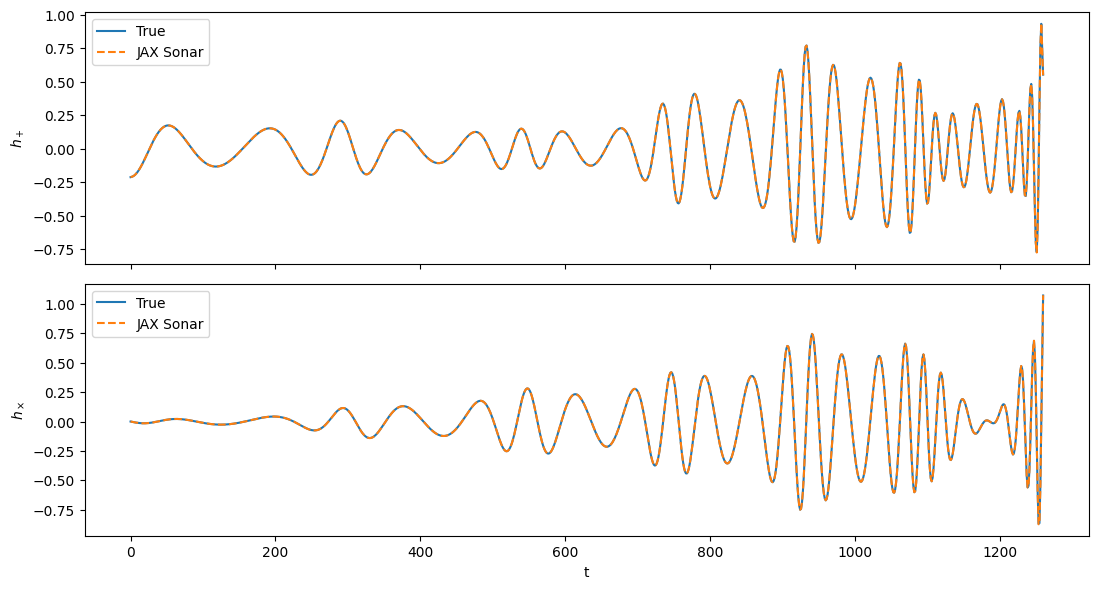

In [ ]:
(final_loss, (final_components, final_roots, final_shell, u0_fit)) = loss_only(
    params, t_full, hp_full, hc_full, LOSS_WEIGHTS
)
final_loss.block_until_ready()
print("final loss:", float(final_loss))
print("raw [waveform, Ricci, frequency, boundary]:", np.asarray(final_components))
print("mean horizon proxy:", float(jnp.mean(final_roots)))

errors = np.asarray(metric_errors_jit(params))
labels = ["g_tt", "g_rr", "g_thth", "g_phph", "g_tph"]
radii = [2, 3, 4, 5, 6, 12, 20]
print("\nMetric relative L2 error across theta (%)")
print("component", *[f"r={r}" for r in radii])
for label, row in zip(labels, errors):
    print(label, *[f"{x:.3f}" for x in row])

trajectory = jax.jit(integrate_network)(
    params["metric"], u0_fit, t_full
)
hp_pred, hc_pred = jax.vmap(
    lambda theta: create_gravityWave(t_full, trajectory, a_true, theta_obs=theta)
)(theta_observed.astype(t_full.dtype))

print("Recovered u0:", np.asarray(u0_fit))
print("True u0:", np.asarray(U0))
print("Mass shell:", float(final_shell))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(np.asarray(t_full), np.asarray(hp_full[0]), label="True")
axes[0].plot(np.asarray(t_full), np.asarray(hp_pred[0]), "--", label="JAX Sonar")
axes[0].set_ylabel(r"$h_+$")
axes[0].legend()
axes[1].plot(np.asarray(t_full), np.asarray(hc_full[0]), label="True")
axes[1].plot(np.asarray(t_full), np.asarray(hc_pred[0]), "--", label="JAX Sonar")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("t")
axes[1].legend()
plt.tight_layout()

save_checkpoint(FINAL_PATH, params, len(schedule) - 1, schedule[-1][1] - 1, n, histories)
print("saved:", FINAL_PATH)

In [ ]:
def rel_L2(hp, hc):
    true = hp_full[0] + 1j * hc_full[0]
    pred = hp + 1j * hc
    return 100 * jnp.linalg.norm(pred - true) / jnp.linalg.norm(true)

def wave(traj):
    return create_gravityWave(
        t_full, traj, a_true,
        theta_obs=theta_observed[0].astype(t_full.dtype),
    )

u_true = U0.astype(t_full.dtype)
u_fit  = u0_fit.astype(t_full.dtype)

cases = {
    "Kerr metric + true IC":
        wave(jax.jit(integrate_kerr)(u_true, t_full)),

    "Kerr metric + learned IC":
        wave(jax.jit(integrate_kerr)(u_fit, t_full)),

    "Learned metric + true IC":
        wave(jax.jit(integrate_network)(params["metric"], u_true, t_full)),

    "Learned metric + learned IC":
        wave(jax.jit(integrate_network)(params["metric"], u_fit, t_full)),
}

for name, (hp, hc) in cases.items():
    print(f"{name:30s}: {float(rel_L2(hp, hc)):.6f}%")

Kerr metric + true IC         : 0.357563%
Kerr metric + learned IC      : 75.849186%
Learned metric + true IC      : 79.391779%
Learned metric + learned IC   : 0.188425%


## Runtime notes

- The first call for each new `(window length, dtype)` includes XLA compilation.
- Later calls reuse the compiled executable.
- BFGS retains float64 because the original notebook explicitly required it.
  On T4-class GPUs float64 may be slower than CPU; benchmark the BFGS phase.
- Full 96-point Ricci and 320-point boundary grids remain unchanged.
- No stochastic Ricci subsampling: BFGS sees a deterministic objective.